In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent, detrend
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression import (
    SymbolicRegressor,
    TemplateConfig,
    PySRParams,
    ModelParametrizer,
)

from sympy import Matrix, Float, preorder_traversal
from warnings import catch_warnings, simplefilter

from numpy import array, float64, ceil, sqrt, log, std, random, isclose
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import cProfile

_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
parser = ModelParser("../MODELS/POST82.yaml")
model, kalman = parser.get_all()

with catch_warnings():
    # Equations in a sp.Matrix are deprecated, this is only used as a pretty print function
    simplefilter(action="ignore")
    mat = Matrix(model.equations.model)
mat

parser.update_calibration_parameters(model, 3, "./tmp.yaml")

In [3]:
fred = FRED(
    key_env=None,  # None => look for the ".env" file. If you have a custom env file, provide its path here.
    key_name="FRED_KEY",  # Name of the variable in the env file that contains the FRED API key.
)
df = fred.get_frame(
    series_ids=[
        "A939RX0Q048SBEA",  # Real GDP per Cap.
        "CPIAUCSL",  # Consumer Price Index for All Urban Consumers: All Items
        "FEDFUNDS",  # Effective Federal Funds Rate
    ],
    date_range=(
        "1955-01-01",
        "2007-10-01",
    ),  # Date range for the data ("YYYY-MM-DD" format or a pd.DatetimeIndex object)
)

gdp_q = df["A939RX0Q048SBEA"]  # already quarterly in most pulls; verify freq

cpi_q = df["CPIAUCSL"].resample("QS").mean()  # quarterly avg CPI
ffr_q = df["FEDFUNDS"].resample("QS").mean()  # quarterly avg policy rate

idx_range = pd.date_range(start="1984-01-01", end="2007-01-01", freq="QS")


df = pd.DataFrame(
    {
        "A939RX0Q048SBEA": gdp_q.reindex(idx_range),
        "CPIAUCSL": cpi_q.reindex(idx_range),
        "FEDFUNDS": ffr_q.reindex(idx_range),
    }
)

df

,A939RX0Q048SBEA,CPIAUCSL,FEDFUNDS
1984-01-01,34103.0,102.533333,9.686667
1984-04-01,34622.0,103.500000,10.556667
1984-07-01,34871.0,104.400000,11.390000
1984-10-01,35072.0,105.300000,9.266667
1985-01-01,35346.0,106.266667,8.476667
...,...,...,...
2006-01-01,54927.0,199.466667,4.456667
2006-04-01,54945.0,201.266667,4.906667
2006-07-01,54886.0,203.166667,5.246667
2006-10-01,55216.0,202.333333,5.246667


In [4]:
x_trend = HP_two_sided(log(df["A939RX0Q048SBEA"]), lamb=1600)[
    0
]  # returns (trend, cycle)
x = (
    log(df["A939RX0Q048SBEA"]) - x_trend
) * 100  # HP detrended quarterly log output gap


inf_lvl = annualized_log_percent(df["CPIAUCSL"], periods_per_year=4)
rate_lvl = df["FEDFUNDS"]

r_ss = model.calibration.parameters["r_star"]
pi_ss = model.calibration.parameters["pi_star"]

rate = (rate_lvl - (r_ss + pi_ss)) / 4  # gap to steady state
inf = (inf_lvl - pi_ss) / 4  # gap to steady state

df_model_units = pd.DataFrame(
    {
        "r": rate,
        "Pi": inf,
        "x": x,
    }
).dropna()

observed = pd.DataFrame(
    {
        "OutGap": df_model_units["x"],
        "Infl": inf_lvl[df_model_units.index],
        "Rate": rate_lvl[df_model_units.index],
    }
)
observed.index = df_model_units.index

In [5]:
prior_spec = {
    # (0, 1)
    "beta": make_prior(
        "beta",
        parameters={"a": 100 * 0.99, "b": 100 * 0.001},
        transform="logit",
    ),
    "rho_r": make_prior(
        "beta",
        parameters={"a": 100 * 0.84, "b": 100 * 0.16},
        transform="logit",
    ),
    "rho_g": make_prior(
        "beta",
        parameters={"a": 100 * 0.83, "b": 100 * 0.17},
        transform="logit",
    ),
    "rho_z": make_prior(
        "beta",
        parameters={"a": 100 * 0.85, "b": 100 * 0.15},
        transform="logit",
    ),
    # (0, +inf)
    "psi_pi": make_prior(
        "gamma",
        parameters={"mean": 2.19, "std": 0.5},
        transform="log",
    ),
    "psi_x": make_prior(
        "gamma",
        parameters={"mean": 0.30, "std": 0.1},
        transform="log",
    ),
    "kappa": make_prior(
        "gamma",
        parameters={"mean": 0.58, "std": 0.1},
        transform="log",
    ),
    "tau_inv": make_prior(
        "gamma",
        parameters={"mean": 1.86, "std": 0.5},
        transform="log",
    ),
    # Correlation (-1,1)
    "rho_gz": make_prior(
        "trunc_normal",
        parameters={"mean": 0.0, "std": 0.20, "low": -1.0, "high": 1.0},
        transform="affine_logit",
        transform_kwargs={
            "low": -1.0,
            "high": 1.0,
        },
    ),
    # Shock std devs (0, +inf)
    "sig_r": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_g": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_z": make_prior(
        "gamma",
        parameters={"mean": 0.64, "std": 0.1},
        transform="log",
    ),
    "meas_outgap": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.1},
        transform="log",
    ),
    "meas_infl": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.1},
        transform="log",
    ),
    "meas_rate": make_prior(
        "gamma",
        parameters={"mean": 0.5, "std": 0.1},
        transform="log",
    ),
    "R_corr": make_prior(
        "lkj_chol",
        parameters={"eta": 1.0, "K": 3},
        transform="cholesky_corr",
    ),
}

solver = DSGESolver(model, kalman)
comp = solver.compile(
    n_exog=3,
    n_state=3,
)
estim = lambda: solver.estimate_and_solve(
    compiled=comp,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(prior_spec.keys()),
    n_draws=25_000,
    burn_in=10_000,
    thin=1,
    update_R_in_iterations=True,
)
res, sol = estim()
# cProfile.run("res, sol = estim()", sort="cumtime")

MCMC sampling concluded in 36.89 seconds with 948.70 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [6]:
param_names = res.param_names

best_idx = np.argmax(res.logpost_trace)

post_mean = np.mean(res.samples, axis=0)
loglik = np.mean(res.logpost_trace)
accept_rate = res.accept_rate
n_draws = res.n_draws
burn_in = res.burn_in
thin = res.thin

param_to_val = dict(zip(param_names, post_mean))


pd.Series(
    {
        **param_to_val,
        "loglik": loglik,
        "accept_rate": accept_rate,
        "n_draws": n_draws,
        "burn_in": burn_in,
        "thin": thin,
    }
)

beta               0.995773
rho_r              0.737501
rho_g              0.901575
rho_z              0.875588
psi_pi             4.102387
psi_x              0.355893
kappa              0.369599
tau_inv            0.509527
rho_gz             0.427626
sig_r              0.032183
sig_g              0.103596
sig_z              0.443453
meas_outgap        0.245245
meas_infl          1.212940
meas_rate          0.221090
meas_rho_gi       -0.085020
meas_rho_gr        0.226461
meas_rho_ir        0.284157
loglik          -361.878369
accept_rate        0.210714
n_draws        25000.000000
burn_in        10000.000000
thin               1.000000
dtype: float64

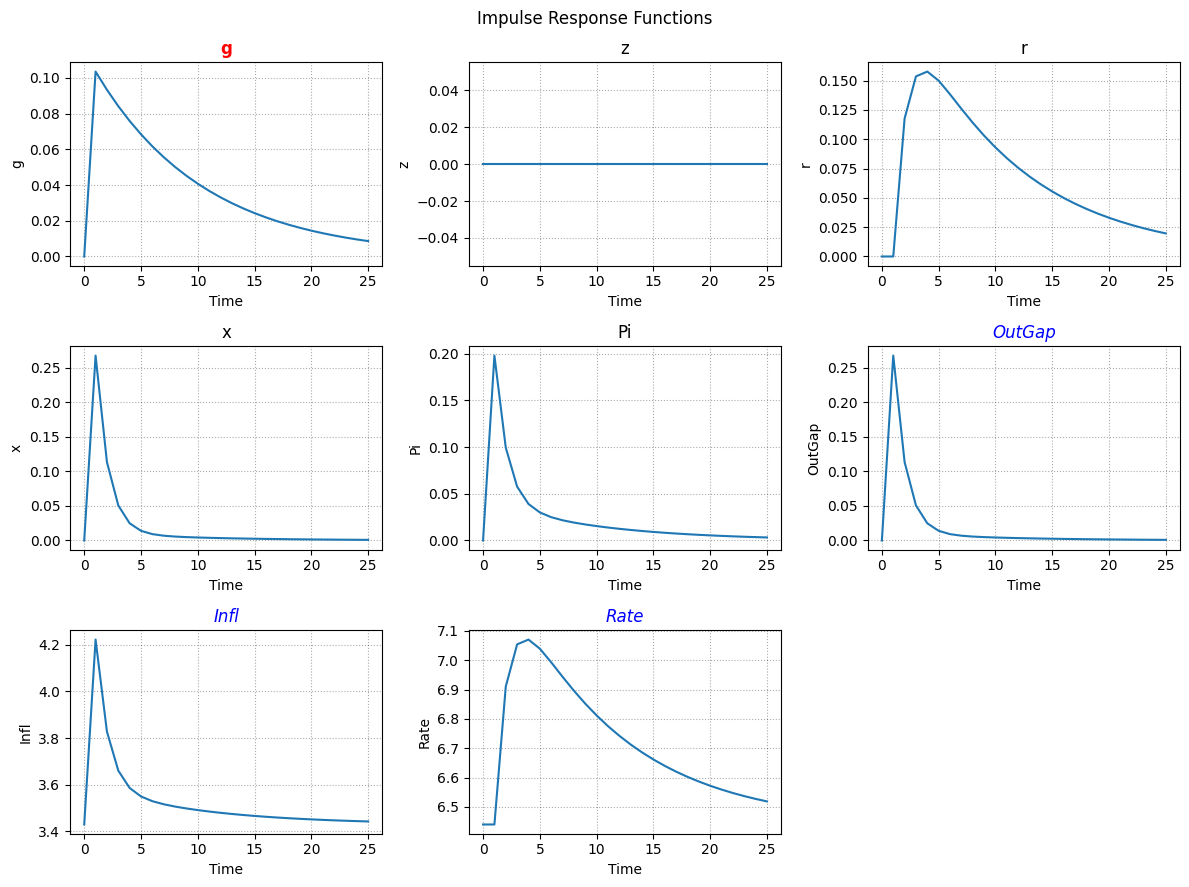

In [7]:
sol.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [8]:
sol.config.calibration.parameters

{beta: np.float64(0.9957734423000375),
 kappa: np.float64(0.36959941779100164),
 tau_inv: np.float64(0.5095274600881269),
 psi_pi: np.float64(4.102386833746515),
 psi_x: np.float64(0.3558927904733072),
 rho_r: np.float64(0.7375006993636346),
 rho_g: np.float64(0.9015751589650902),
 rho_z: np.float64(0.8755879715741539),
 pi_star: np.float64(3.43),
 r_star: np.float64(3.01),
 sig_r: np.float64(0.032183456174868015),
 sig_g: np.float64(0.10359555159854529),
 sig_z: np.float64(0.4434531172724118),
 rho_gz: np.float64(0.42762626420378624),
 meas_infl: np.float64(1.2129398660525912),
 meas_rate: np.float64(0.22109009772159618),
 meas_outgap: np.float64(0.24524466056346458),
 meas_rho_ir: np.float64(0.28415746362178396),
 meas_rho_gi: np.float64(-0.08501971668570286),
 meas_rho_gr: np.float64(0.22646090955486337)}

In [9]:
kf = sol.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "linear",
    return_shocks=True,
)

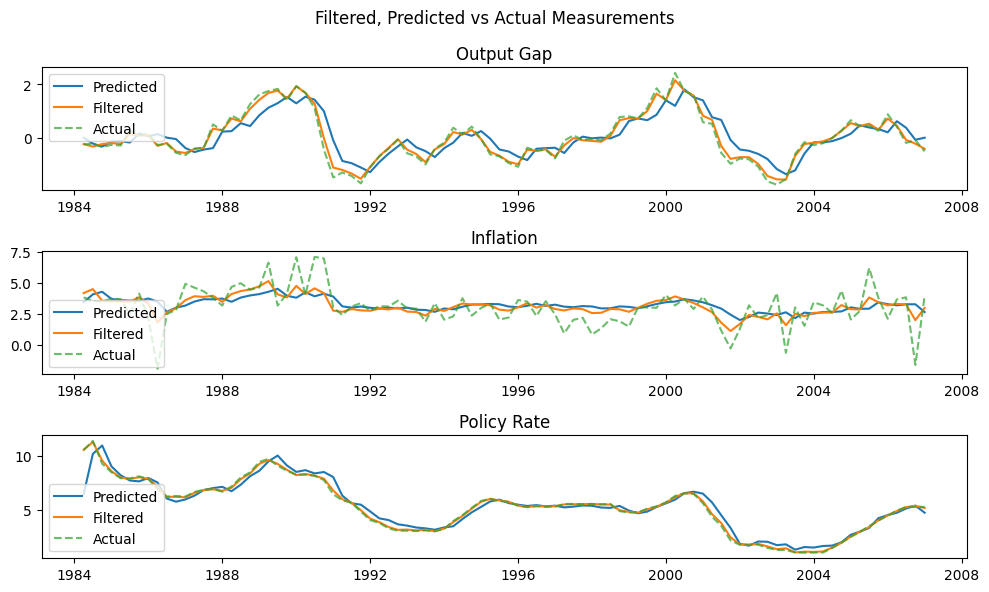

In [10]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

In [11]:
gz = Shock(T=len(idx) - 1, dist="norm", multivar=True, seed=0).shock_generator()
r = Shock(T=len(idx) - 1, dist="norm", seed=1).shock_generator()
sim = sol.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)

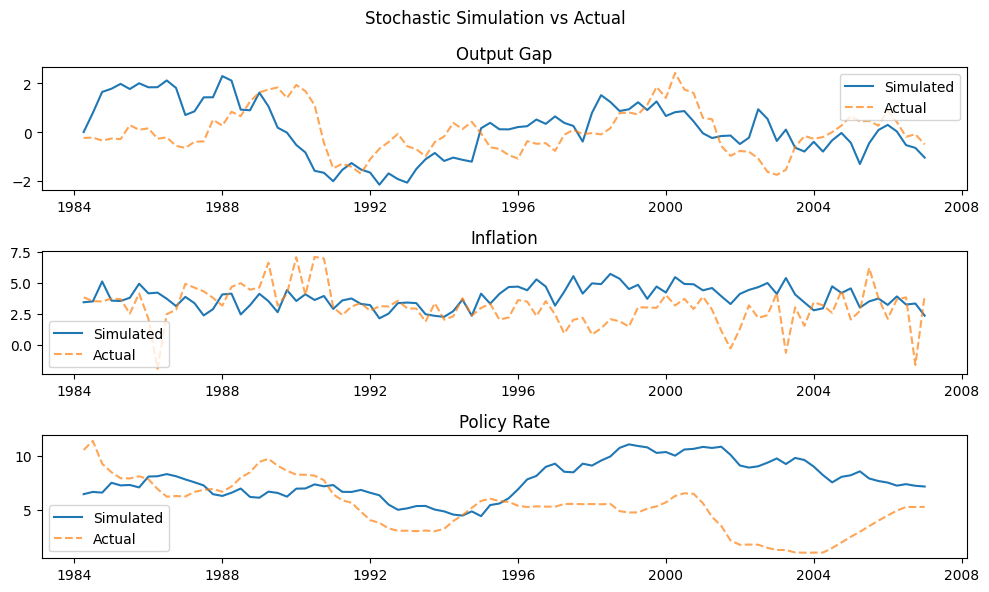

In [12]:
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Stochastic Simulation vs Actual")

ax[0].plot(idx, sim["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, sim["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

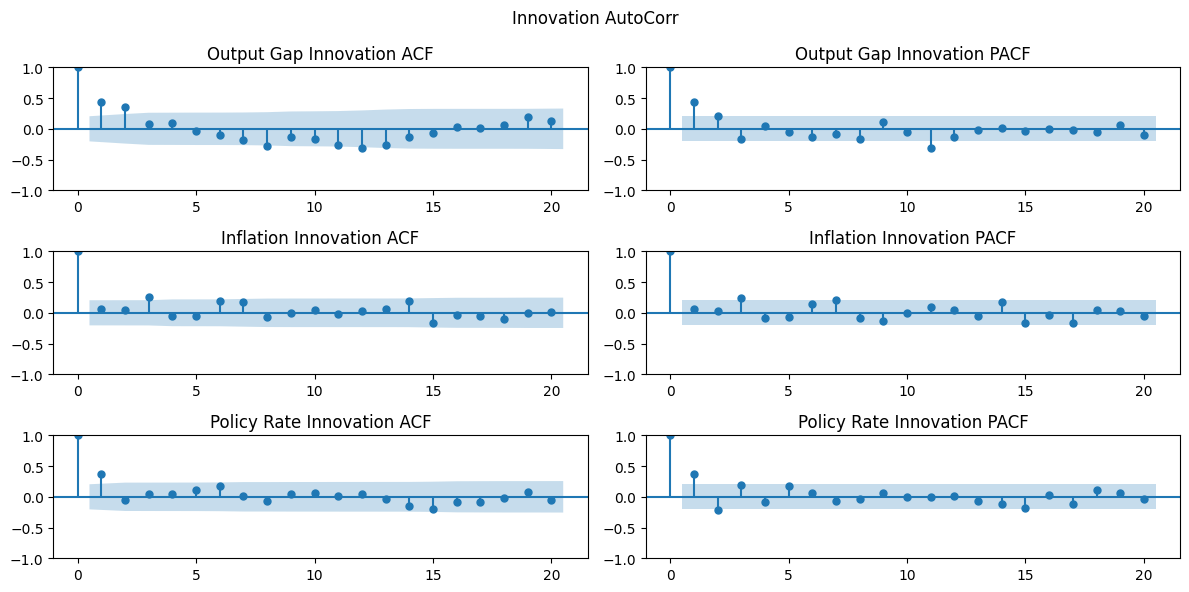

In [13]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Innovation AutoCorr")
plot_acf(
    kf.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovation ACF",
)
plot_acf(
    kf.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovation ACF",
)
plot_acf(
    kf.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovation ACF",
)
plot_pacf(
    kf.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovation PACF",
)
plot_pacf(
    kf.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovation PACF",
)
plot_pacf(
    kf.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovation PACF",
)

plt.tight_layout()

In [89]:
template = TemplateConfig(
    include_expression=False,
    interaction_form="func",
    hessian_restriction="free",
    power_law_lower_bound=2,
    power_law_upper_bound=2,
    powers_in_interactions=False,
    constant_filtering="parametrize_all",
    model_complexity_bound=20,
)

params = PySRParams(
    niterations=500,
    maxsize=20,
    complexity_of_constants=3,
    complexity_of_variables=1,
    deterministic=True,
    random_state=0,
    parallelism="serial",
)

sr_discovery = lambda obs: sol.fit_kf(
    template_config=template,
    sr_params=params,
    y=observed.loc[observed.index >= "1984-01-01", :],
    variables=["r", "Pi", "x"],
    observable=obs,
).expressions

r_sr = sr_discovery("Rate")
x_sr = sr_discovery("OutGap")
# pi_sr = sr_discovery("Infl")  # Only running sr for observables with innovation autocorrelation.

/Users/guneykiymac/Desktop/Portfolio/SymbolicDSGE/.venv/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.020e+05
Progress: 1906 / 15500 total iterations (12.297%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.501e-01  0.000e+00  f_1 = #3
3           4.395e-01  1.185e-02  f_1 = -0.089619
5           4.214e-01  2.103e-02  f_1 = (#3 - #1) * #3
7           4.142e-01  8.682e-03  f_1 = (#3 + #3) * (#3 - #1)
9           4.071e-01  8.600e-03  f_1 = (#3 * #1) / (#3 + -0.55181)
11          4.056e-01  1.825e-03  f_1 = (#3 * (#1 - #3)) / (#3 + -0.4544)
13          4.021e-01  4.330e-03  f_1 = #3 * ((#3 / ((#1 + -0.52182) + #3)) - #2)
15          3.629e-01  5.129e-02  f_1 = -0.00041052 / (-0.00041052 + ((#1 - 2.3212) * #3))
17          3.627e-01  2.864e-04  f_1 = -0.00041052 / (-0.00041052 + (((#2 * #1) - 2.3212) * #3)...
                                  )


[ Info: Final population:
[ Info: Results saved to:
/Users/guneykiymac/Desktop/Portfolio/SymbolicDSGE/.venv/lib/python3.13/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.070e+05
Progress: 1939 / 15500 total iterations (12.510%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.332e-01  0.000e+00  f_1 = #3
5           2.310e-01  2.463e-03  f_1 = #3 * 0.64998
7           2.265e-01  9.829e-03  f_1 = (#1 * -0.13295) + #3
9           2.102e-01  3.718e-02  f_1 = (#3 * #3) / (#2 - 1.0127)
11          2.066e-01  8.735e-03  f_1 = #3 + (#3 * (#3 / (#2 - 1.0101)))
13          2.040e-01  6.393e-03  f_1 = #3 * ((#3 / (#2 - 1.0099)) + 0.57711)
15          2.019e-01  5.202e-03  f_1 = #3 + ((#1 - (#3 / (0.98145 - #2))) * -0.098931)
17          2.000e-01  4.590e-03  f_1 = #3 + ((#1 - ((#3 / (0.98145 - #2)) + #2)) * -0.098931)
19          1.988e-01  3.103e-03  f_1 = ((#1 - ((#3 / (0.98145 - #2)) + (#2 - #1))) * -0.098931)...
    

[ Info: Final population:
[ Info: Results saved to:


  - /var/folders/_8/plljqz697vd66bfjdlkc12qm0000gn/T/tmpactvqt8k/20260318_145006_xWeOR8/hall_of_fame.csv


In [86]:
def sum_moments(series):
    out = pd.Series()

    out["mean"] = series.mean()
    out["var"] = series.var()
    out["Q1"] = series.quantile(0.25)
    out["Median"] = series.median()
    out["Q3"] = series.quantile(0.75)
    out["IQR"] = out["Q3"] - out["Q1"]
    return out.round(2)


sum_moments(pd.Series(kf.y_filt[:, 1]))

mean      3.13
var       0.55
Q1        2.67
Median    3.00
Q3        3.55
IQR       0.88
dtype: float64

In [87]:
def walk_round(x, n=3):
    for atom in preorder_traversal(x):
        if isinstance(atom, Float):
            x = x.subs(atom, round(atom, n))
    return x


r_sr["initial_expr"] = res["initial_expr"].apply(lambda x: walk_round(x, n=3))
r_sr[["initial_expr", "sympy_format", "loss", "complexity"]]

,initial_expr,sympy_format,loss,complexity
0,x,x,0.450083,1
1,-0.090,_C_1,0.439545,3
2,x*(-r + x),x*(_C_1*r + x),0.421439,5
3,2*x*(-r + x),_C_1*x*(_C_2*r + x),0.414184,7
4,x/(Pi - r + 1.324),_C_1/(_C_2 + r),0.257954,9
5,NaN,_C_1/(_C_2 + Pi + x),0.253770,11
6,NaN,_C_1/(_C_2 + r) + _C_3*r*x,0.227681,13
7,NaN,_C_1/(_C_2 + Pi + x) + _C_3*r*x,0.222598,15
8,NaN,_C_1/(_C_2 + Pi + x) + _C_3*x*(r + x),0.220543,17
9,NaN,_C_1/(_C_2 + Pi*x + Pi + x) + _C_3*r*x,0.215462,19


In [88]:
x_sr["initial_expr"] = res["initial_expr"].apply(lambda x: walk_round(x, n=3))
x_sr[["initial_expr", "sympy_format", "loss", "complexity"]]

,initial_expr,sympy_format,loss,complexity
0,x,x,0.233243,1
1,-0.090,_C_1*x,0.230956,5
2,x*(-r + x),_C_1*r + x,0.226460,7
3,2*x*(-r + x),x**_C_1/(_C_2 + Pi),0.210196,9
4,x/(Pi - r + 1.324),x + x**_C_1/(_C_2 + Pi),0.206510,11
5,NaN,x*(_C_1 + x/(_C_2 + Pi)),0.203603,13
6,NaN,_C_1*x/(_C_2 + _C_3*Pi + x) + x,0.199456,15
7,NaN,_C_1*r + _C_2*x/(_C_3 + _C_4*Pi + x) + x,0.194083,17
8,NaN,_C_1*Pi + _C_2*r + _C_3*x/(_C_4 + _C_5*Pi + x)...,0.192192,19


In [65]:
# Augmented Model
conf_aug, kalman_aug = ModelParser(
    "../sdsge-papers/progress/report1/Augmented.yaml"
).get_all()
solver_aug = DSGESolver(conf_aug, kalman_aug)
comp_aug = solver_aug.compile(n_exog=3, n_state=3)

aug = solver_aug.solve(compiled=comp_aug)  # Solve without re-estimation

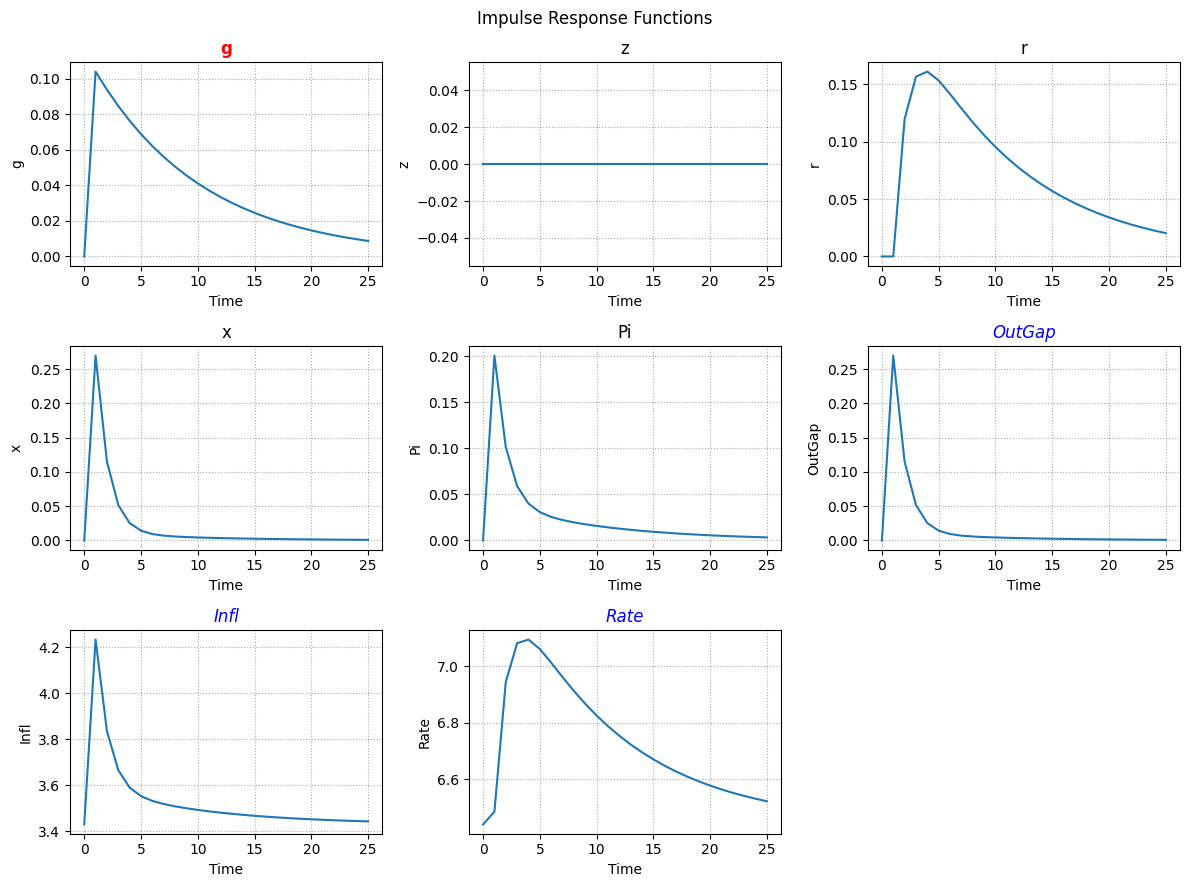

In [66]:
aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [67]:
kf_aug = aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

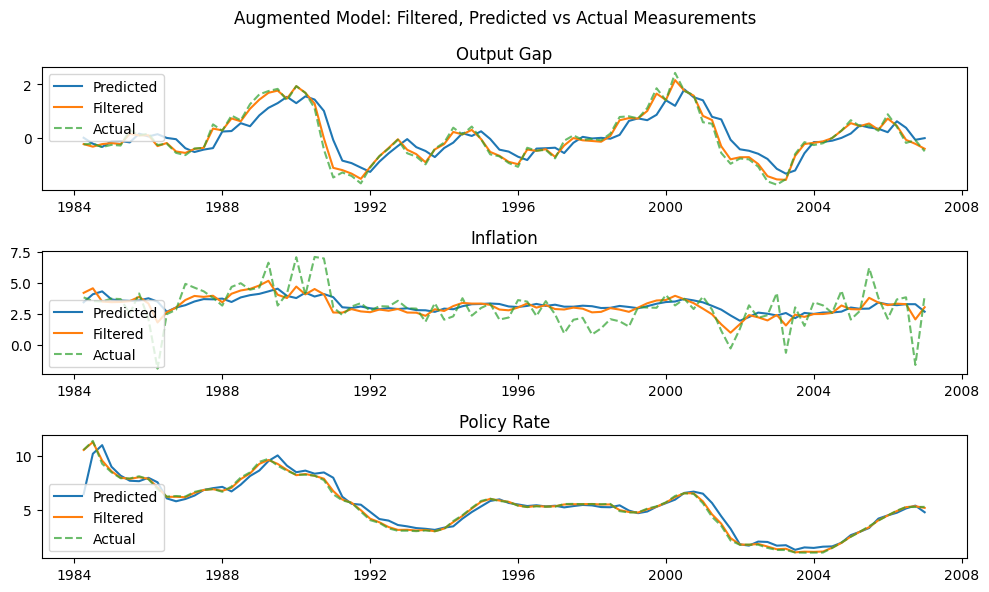

In [68]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented Model: Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_aug.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf_aug.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_aug.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf_aug.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf_aug.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf_aug.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

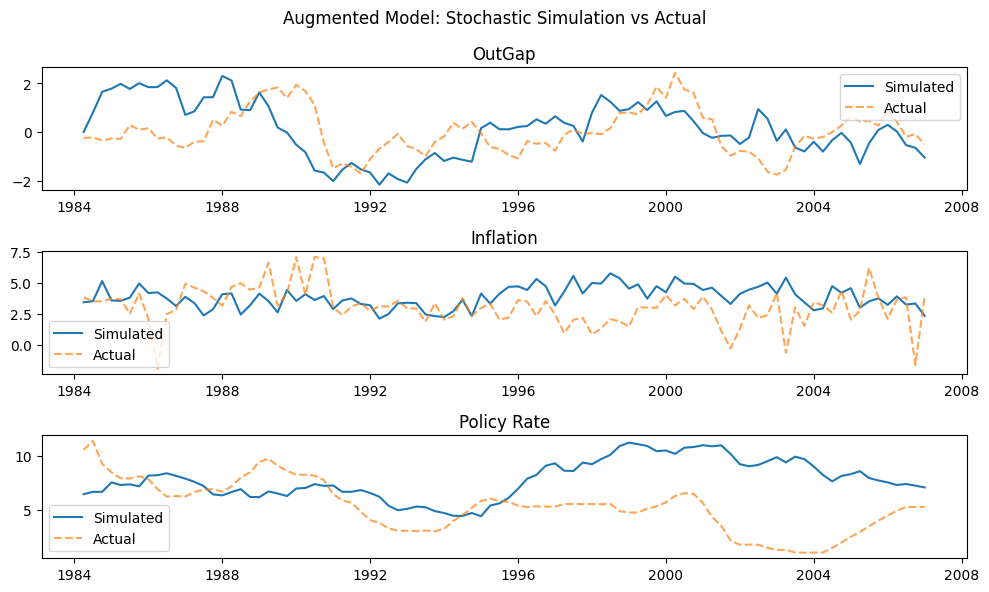

In [69]:
sim_aug = aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("OutGap")
ax[0].legend()

ax[1].plot(idx, sim_aug["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim_aug["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

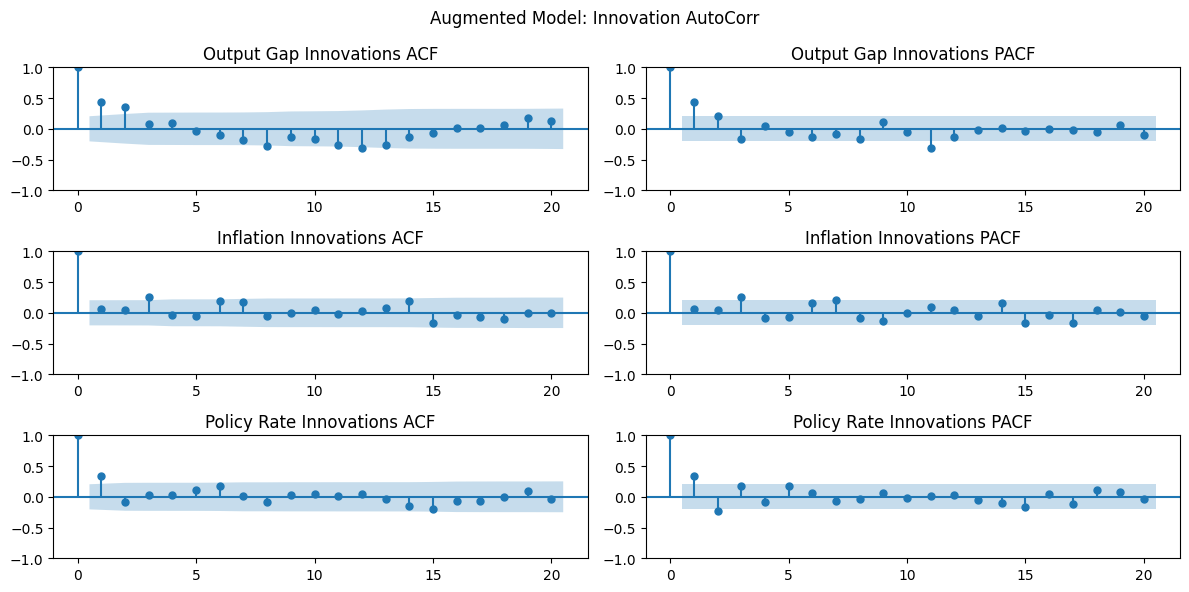

In [70]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Augmented Model: Innovation AutoCorr")

plot_acf(
    kf_aug.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovations ACF",
)
plot_acf(
    kf_aug.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovations ACF",
)
plot_acf(
    kf_aug.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovations ACF",
)
plot_pacf(
    kf_aug.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovations PACF",
)
plot_pacf(
    kf_aug.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovations PACF",
)
plot_pacf(
    kf_aug.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovations PACF",
)

plt.tight_layout()

In [71]:
sum_moments(pd.Series(sim_aug["Infl"]))

mean      3.85
var       0.76
Q1        3.29
Median    3.84
Q3        4.46
IQR       1.17
dtype: float64

In [72]:
# Augmented + Re-estimated model
aug_priors = {
    **prior_spec,
    **{
        "pi_const": make_prior(
            "normal",
            parameters={"mean": -0.282, "std": 0.1},
            transform="identity",
        ),
    },
}

res_aug, sol_aug = solver_aug.estimate_and_solve(
    compiled=comp_aug,
    y=observed.loc[observed.index >= "1984-01-01", :],
    priors=aug_priors,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    estimated_params=list(aug_priors.keys()),
    n_draws=25_000,
    burn_in=10_000,
    thin=1,
)

MCMC sampling concluded in 33.72 seconds with 1037.95 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [73]:
# Summarize results
param_names_aug = res_aug.param_names
post_mean_aug = np.mean(res_aug.samples, axis=0)
loglik_aug = np.mean(res_aug.logpost_trace)
accept_rate_aug = res_aug.accept_rate
pd.Series(
    {
        **dict(zip(param_names_aug, post_mean_aug)),
        "loglik": loglik_aug,
        "accept_rate": accept_rate_aug,
        "n_draws": res_aug.n_draws,
        "burn_in": res_aug.burn_in,
        "thin": res_aug.thin,
    }
)

beta               0.998669
rho_r              0.724314
rho_g              0.895851
rho_z              0.869789
psi_pi             3.901109
psi_x              0.340277
kappa              0.431866
tau_inv            0.518395
rho_gz             0.385852
sig_r              0.030037
sig_g              0.108050
sig_z              0.464465
meas_outgap        0.492350
meas_infl          0.504512
meas_rate          0.498834
meas_rho_gi       -0.001767
meas_rho_gr        0.027446
meas_rho_ir       -0.003620
pi_const          -0.434062
loglik          -314.160733
accept_rate        0.293914
n_draws        25000.000000
burn_in        10000.000000
thin               1.000000
dtype: float64

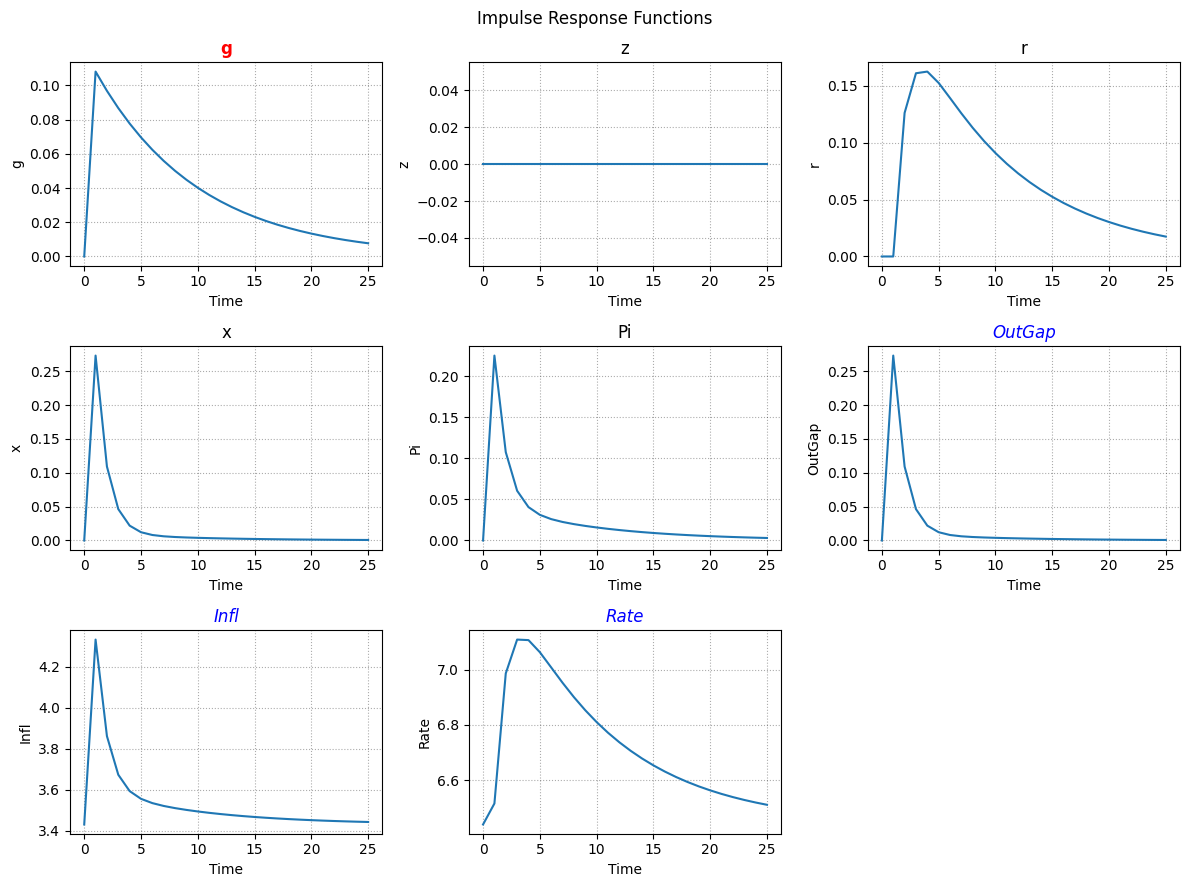

In [74]:
sol_aug.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [75]:
kf_aug_reest = sol_aug.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "extended",
    return_shocks=True,
)

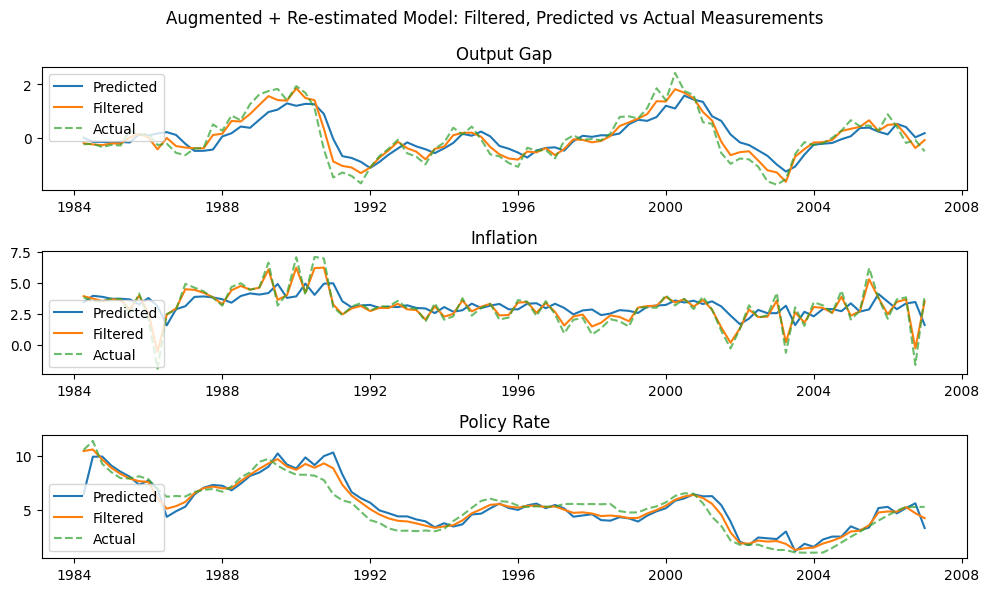

In [76]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle(
    "Augmented + Re-estimated Model: Filtered, Predicted vs Actual Measurements"
)

ax[0].plot(idx, kf_aug_reest.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, kf_aug_reest.y_filt[:, 0], label="Filtered")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(idx, kf_aug_reest.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, kf_aug_reest.y_filt[:, 1], label="Filtered")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, kf_aug_reest.y_pred[:, 2], label="Predicted")
ax[2].plot(idx, kf_aug_reest.y_filt[:, 2], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

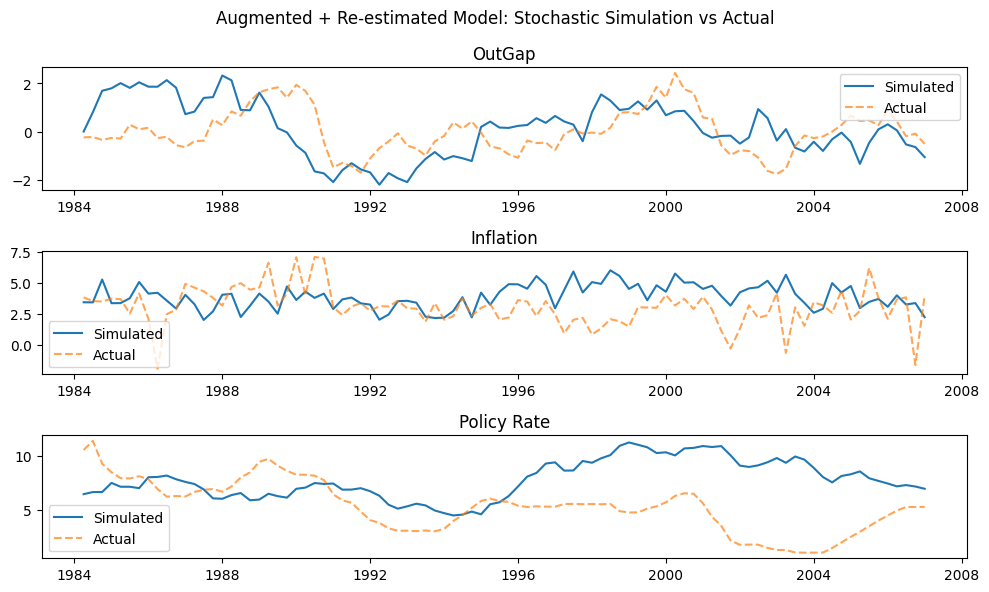

In [77]:
sim_aug_reest = sol_aug.sim(
    T=len(idx) - 1,
    shocks={"g,z": gz, "r": r},
    observables=True,
)
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

plt.suptitle("Augmented + Re-estimated Model: Stochastic Simulation vs Actual")

ax[0].plot(idx, sim_aug_reest["OutGap"], label="Simulated")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("OutGap")
ax[0].legend()

ax[1].plot(idx, sim_aug_reest["Infl"], label="Simulated")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(idx, sim_aug_reest["Rate"], label="Simulated")
ax[2].plot(idx, obs.iloc[:, 2], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Policy Rate")
ax[2].legend()

plt.tight_layout()

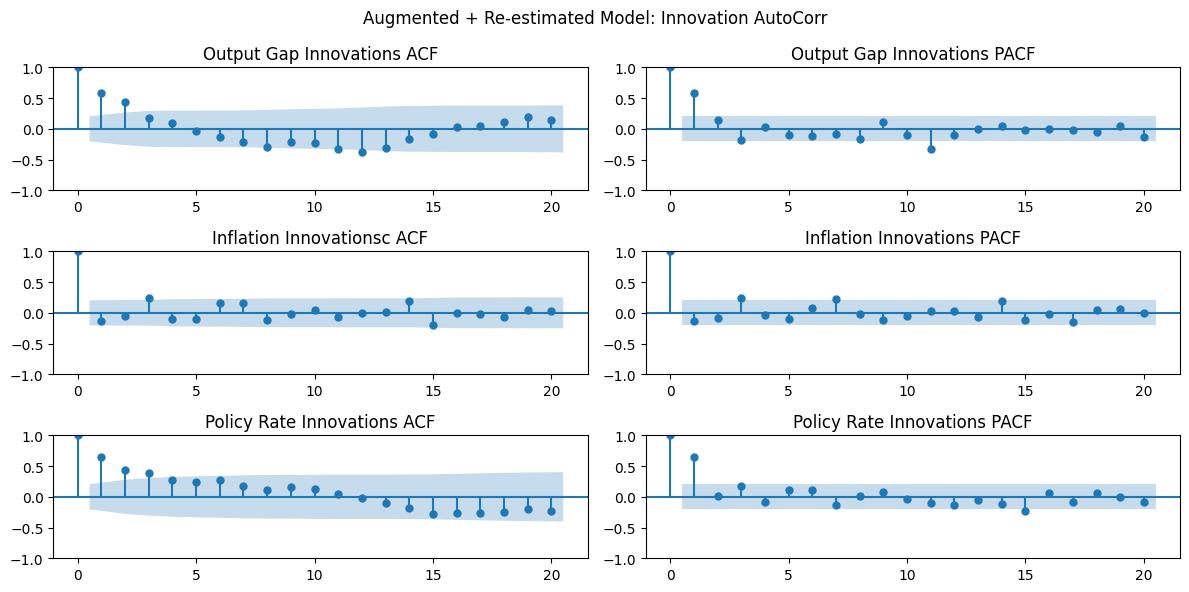

In [78]:
fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plt.suptitle("Augmented + Re-estimated Model: Innovation AutoCorr")
plot_acf(
    kf_aug_reest.innov[:, 0],
    ax=ax[0, 0],
    lags=20,
    title="Output Gap Innovations ACF",
)
plot_acf(
    kf_aug_reest.innov[:, 1],
    ax=ax[1, 0],
    lags=20,
    title="Inflation Innovationsc ACF",
)
plot_acf(
    kf_aug_reest.innov[:, 2],
    ax=ax[2, 0],
    lags=20,
    title="Policy Rate Innovations ACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 0],
    ax=ax[0, 1],
    lags=20,
    title="Output Gap Innovations PACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 1],
    ax=ax[1, 1],
    lags=20,
    title="Inflation Innovations PACF",
)
plot_pacf(
    kf_aug_reest.innov[:, 2],
    ax=ax[2, 1],
    lags=20,
    title="Policy Rate Innovations PACF",
)

plt.tight_layout()

In [54]:
res_aug.hpd_intervals()

{'beta': (np.float64(0.9980974986435094), np.float64(0.9999310863275153)),
 'rho_r': (np.float64(0.7566571247692176), np.float64(0.8874729384637178)),
 'rho_g': (np.float64(0.8425290983456298), np.float64(0.9163360938545002)),
 'rho_z': (np.float64(0.8292196574778231), np.float64(0.9111776098481941)),
 'psi_pi': (np.float64(1.3655692081045372), np.float64(3.2981119987624066)),
 'psi_x': (np.float64(0.19417275112263271), np.float64(0.5333129973364483)),
 'kappa': (np.float64(0.31253268837149667), np.float64(0.6363796679047323)),
 'tau_inv': (np.float64(0.7040626906454683), np.float64(1.5081410005610179)),
 'rho_gz': (np.float64(0.753565645028071), np.float64(0.9801319426898263)),
 'sig_r': (np.float64(0.02489641927720672), np.float64(0.06661003365595138)),
 'sig_g': (np.float64(0.038793508049683345), np.float64(0.08110173189918223)),
 'sig_z': (np.float64(0.34815990745126824), np.float64(0.4889675240826519)),
 'meas_outgap': (np.float64(0.311349252722754),
  np.float64(0.699552512405008